In [9]:
from general_settings import *

In [10]:
# Define priors:
f = lambda x, y:  0.01 * np.exp(-(np.abs(x[0] - y[0]) + np.abs(x[1] - y[1]))/0.1) 
grid = V.tabulate_dof_coordinates()
covariance = comp_covariance(grid, f)
eigvals, eigvecs = np.linalg.eigh(covariance)
eigvals_R, eigvecs_R = eigvals[::-1], eigvecs[:, ::-1]
M_array = M_matrix.array()
eigvals_M, eigvecs_M = eigh(M_array)
# Compute M^(-1/2):
M_inv_sqrt = eigvecs_M @ np.diag(1/np.sqrt(eigvals_M)) @ eigvecs_M.T

(array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

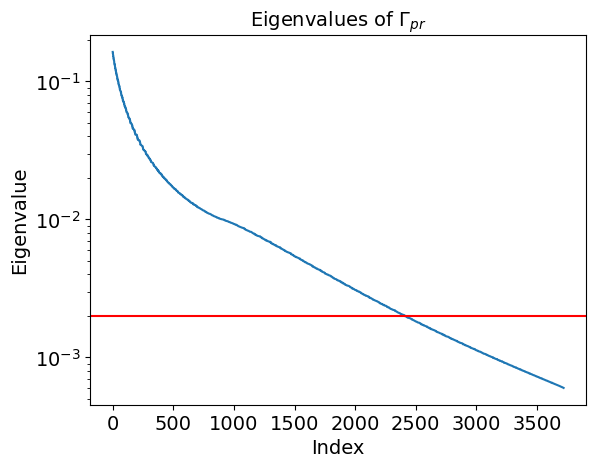

In [11]:
ax = plt.figure()
plt.semilogy(eigvals_R)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Eigenvalue', fontsize=14)
plt.title('Eigenvalues of $\Gamma_{pr}$', fontsize=14)
plt.axhline(y=2*1e-3, color='r', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Export plot to pdf with short marginal:
# plt.savefig('eigenvalues_laplacian.pdf', bbox_inches='tight')

In [12]:
# Define list of eigenvectors:
list_vectors = [init_vector_numpy(M_inv_sqrt @ eigvecs_R[:, i]) for i in range(V.dim())]
omega = np.array([20 * np.pi, 30 * np.pi, 40 * np.pi, 50 * np.pi, 60 * np.pi])
size_omega = len(omega)
list_i_funcs = np.array([np.sin(omega[i] * simulation_times) for i in range(size_omega)])
list_i_prime_funcs = np.array([omega[i] * np.cos(omega[i] * simulation_times) for i in range(size_omega)])

L2_norm_list = np.array([simps(func * func, simulation_times) for func in list_i_funcs])
H1_norm_list = np.array([simps(func * func, simulation_times) for func in list_i_prime_funcs])
print('L2 norm of the functions: ', L2_norm_list)
print('H1 norm of the functions: ', H1_norm_list)

L2 norm of the functions:  [0.05 0.05 0.05 0.05 0.05]
H1 norm of the functions:  [ 197.39208802  444.13219805  789.56835209 1233.70055014 1776.5287922 ]


In [13]:
# Define reference input:
I_0 = 200.
X = np.array([200., 0., 0., 0., 0.])
i_func_ref = list_i_funcs.T.dot(X)
i_prime_func_ref = list_i_prime_funcs.T.dot(X)

# Compute L2 norm of the reference input:
L2_norm_ref = simps(i_func_ref * i_func_ref, simulation_times)
H1_norm_ref = simps(i_prime_func_ref * i_prime_func_ref, simulation_times)
print('L2 norm of the reference function: ', L2_norm_ref)
print('H1 norm of the reference function: ', H1_norm_ref)

L2 norm of the reference function:  2000.0000000000005
H1 norm of the reference function:  7895683.5208714865


In [14]:
c_expr = fn.Constant(c)
# alpha = 0.3 # alpha = 0.3, 0.8
alpha = 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2))
print(b)
# b = 66.08/1e3
b = 31.54/1e3
parameter = [c_expr, b, alpha]
k = 160

31.543866727148018


In [7]:
multi_solution_20 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[0])
list_100 = export_list_time_vectors('data_list/edge_08_20_103.pkl', multi_solution_20)
del multi_solution_20
gc.collect()

multi_solution_30 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[1])
list_200 = export_list_time_vectors('data_list/edge_08_30_103.pkl', multi_solution_30)
del multi_solution_30
gc.collect()

multi_solution_40 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[2])
list_300 = export_list_time_vectors('data_list/edge_08_40_103.pkl', multi_solution_40)
del multi_solution_40
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 
Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 
Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


0

In [8]:
multi_solution_50 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[3])
list_400 = export_list_time_vectors('data_list/edge_08_50_103.pkl', multi_solution_50)
del multi_solution_50
gc.collect()

multi_solution_60 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[4])
list_500 = export_list_time_vectors('data_list/edge_08_60_103.pkl', multi_solution_60)
del multi_solution_60
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 
Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


0

In [10]:
omega = 80 * np.pi
i_prime = omega * np.cos(omega * simulation_times)
mult_solution_80 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, i_prime)
list_80 = export_list_time_vectors('data_new/edge_03_80_104.pkl', mult_solution_80)
del mult_solution_80
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


66594

In [11]:
omega = 100 * np.pi
i_prime = omega * np.cos(omega * simulation_times)
mult_solution_100 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, i_prime)
list_100 = export_list_time_vectors('data_new/edge_03_100_104.pkl', mult_solution_100)
del mult_solution_100
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


8

In [ ]:
# Load data:
multi_solution_100 = import_list_time_vectors('multi_100_edge_03.pkl', 200, simulation_times, M_matrix)
multi_solution_200 = import_list_time_vectors('multi_200_edge_03.pkl', 200, simulation_times, M_matrix)
multi_solution_300 = import_list_time_vectors('multi_300_edge_03.pkl', 200, simulation_times, M_matrix)
multi_solution_400 = import_list_time_vectors('multi_400_edge_03.pkl', 200, simulation_times, M_matrix)
multi_solution_500 = import_list_time_vectors('multi_500_edge_03.pkl', 200, simulation_times, M_matrix)

In [ ]:
list_FIM_5 = comp_1([multi_solution_100[:k], multi_solution_200[:k], multi_solution_300[:k],
                     multi_solution_400[:k], multi_solution_500[:k]])
# Export the list of FIM to a file:
np.savez('list_FIM_100_200_300_400_500_edge_03.npz', *list_FIM_5)

In [ ]:
list_FIM_5 = np.load('data/list_FIM_100_200_300_400_500_edge_03.npz')
list_FIM_5 = [list_FIM_5[key] for key in list_FIM_5]
variance = 0.01
k = 160
def OED_func_5(x):
    FIM_sum_0 = list_FIM_5[0]
    FIM_sum_1 = list_FIM_5[6]
    FIM_sum_2 = list_FIM_5[12]
    FIM_sum_3 = list_FIM_5[18]
    FIM_sum_4 = list_FIM_5[24]
    FIM_sum_01 = (list_FIM_5[1] + list_FIM_5[5]) / 2
    FIM_sum_02 = (list_FIM_5[2] + list_FIM_5[10]) / 2
    FIM_sum_03 = (list_FIM_5[3] + list_FIM_5[15]) / 2
    FIM_sum_04 = (list_FIM_5[4] + list_FIM_5[20]) / 2
    FIM_sum_12 = (list_FIM_5[7] + list_FIM_5[11]) / 2
    FIM_sum_13 = (list_FIM_5[8] + list_FIM_5[16]) / 2
    FIM_sum_14 = (list_FIM_5[9] + list_FIM_5[21]) / 2
    FIM_sum_23 = (list_FIM_5[13] + list_FIM_5[17]) / 2
    FIM_sum_24 = (list_FIM_5[14] + list_FIM_5[22]) / 2
    FIM_sum_34 = (list_FIM_5[19] + list_FIM_5[23]) / 2
    FIM = (x[0] ** 2 * FIM_sum_0 + x[1] ** 2 * FIM_sum_1 + x[2] ** 2 * FIM_sum_2 + x[3] ** 2 * FIM_sum_3 + x[4] ** 2 * FIM_sum_4
           + 2 * x[0] * x[1] * FIM_sum_01 + 2 * x[0] * x[2] * FIM_sum_02 + 2 * x[0] * x[3] * FIM_sum_03 + 2 * x[0] * x[4] * FIM_sum_04
           + 2 * x[1] * x[2] * FIM_sum_12 + 2 * x[1] * x[3] * FIM_sum_13 + 2 * x[1] * x[4] * FIM_sum_14
           + 2 * x[2] * x[3] * FIM_sum_23 + 2 * x[2] * x[4] * FIM_sum_24 + 2 * x[3] * x[4] * FIM_sum_34) / variance
    prior_mat = np.diag(1/eigvals_R[:k])
    post_mat = FIM + prior_mat
    # Check if post_mat is symmetric:
    assert np.allclose(post_mat, post_mat.T), 'Matrix is not symmetric'
    # Check if post_mat is positive definite:
    assert np.all(np.linalg.eigvals(post_mat) > 0), 'Matrix is not positive definite'
    FIM_inv = inv(post_mat)
    FIM_inv_square = FIM_inv @ FIM_inv
    obj = np.trace(FIM_inv)
    grad_0 = -2 * np.trace(FIM_inv_square @ (x[0] * FIM_sum_0 + x[1] * FIM_sum_01 + x[2] * FIM_sum_02 + x[3] * FIM_sum_03 + x[4] * FIM_sum_04)) / variance
    grad_1 = -2 * np.trace(FIM_inv_square @ (x[0] * FIM_sum_01 + x[1] * FIM_sum_1 + x[2] * FIM_sum_12 + x[3] * FIM_sum_13 + x[4] * FIM_sum_14)) / variance
    grad_2 = -2 * np.trace(FIM_inv_square @ (x[0] * FIM_sum_02 + x[1] * FIM_sum_12 + x[2] * FIM_sum_2 + x[3] * FIM_sum_23 + x[4] * FIM_sum_24)) / variance
    grad_3 = -2 * np.trace(FIM_inv_square @ (x[0] * FIM_sum_03 + x[1] * FIM_sum_13 + x[2] * FIM_sum_23 + x[3] * FIM_sum_3 + x[4] * FIM_sum_34)) / variance
    grad_4 = -2 * np.trace(FIM_inv_square @ (x[0] * FIM_sum_04 + x[1] * FIM_sum_14 + x[2] * FIM_sum_24 + x[3] * FIM_sum_34 + x[4] * FIM_sum_4)) / variance
    return obj, np.array([grad_0, grad_1, grad_2, grad_3, grad_4])

In [ ]:
supp = np.array([0, 2, 3, 4, 5])
# def constraint_1(x):
#     return 400. - np.sum(np.abs(x))

def constraint_1(x):
    return 400. - np.sum(np.abs(x))

def constraint_2(x):
    L2_norm = L2_norm_list[supp]
    H1_norm = H1_norm_list[supp]
    return L2_norm_ref - np.sum(L2_norm * x ** 2) + H1_norm_ref - np.sum(H1_norm * x ** 2)

constraints = [{'type': 'ineq', 'fun': constraint_1},
               {'type': 'ineq', 'fun': constraint_2}]

# OED_opt = lambda x: OED_func_4(x, list_FIM_4, eigvals_R, k)
    
x0 = np.array([100., 0., 0., 0., 0])
# Increase number of iterations:
result_scipy = minimize(OED_func_5, x0, jac=True, constraints=constraints, options={'maxiter': 300}, tol=1e-8)
print(result_scipy)

In [ ]:
print(OED_func_5(result_scipy.x))
print(OED_func_5(x0))
print(OED_func_5([0., 0., 0., 0., 80.]))
print(OED_func_5([0., 0., 0., 0., 0.]))